
# Diseño de software

----

## Diseño de API en `Scikit-learn`
### Estimadores, transformadores y predictores

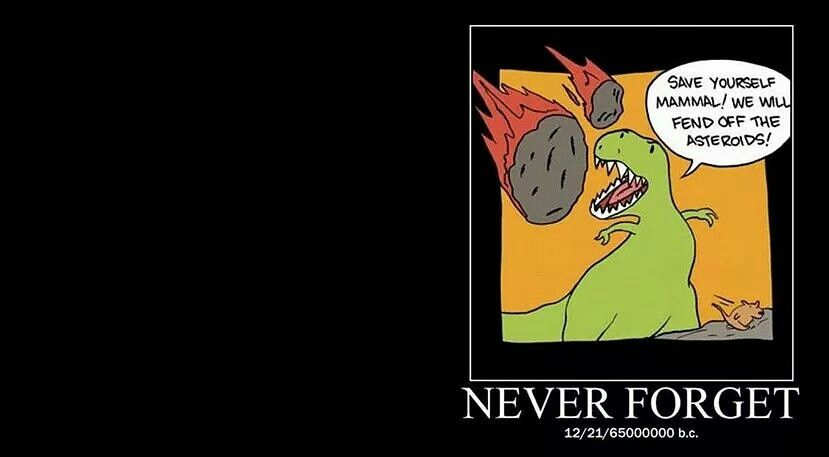


## Diseño de APIs en Machine Learning

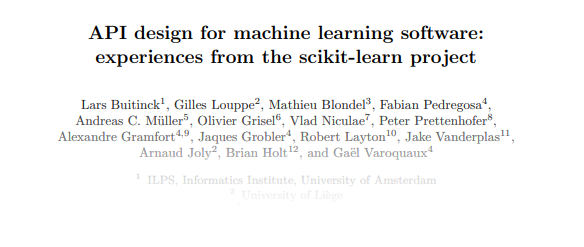

> Buitinck, L., Louppe, G., Blondel, M., Pedregosa, F., Mueller, A., Grisel, O., ... & Varoquaux, G. (2013). API design for machine learning software: experiences from the scikit-learn project. arXiv preprint arXiv:1309.0238.

- Scikit-Learn es una biblioteca de aprendizaje automático de código abierto para Python que se ha convertido en estándar de facto en la industria.
- Una biblioteca que demuestra cómo una API bien diseñada puede simplificar tareas complejas y facilitar la adopción masiva.

 *"Designed to be simple and efficient, accessible to non-experts and reusable in various contexts"*

## 

## Principios de diseño 1/5

1. **Consistencia**
   - Todos los objetos comparten una interfaz común y limitada
   - Documentación consistente para todos los objetos
   - Ejemplo del paper: Todos los estimadores implementan `fit()` y tienen la misma firma

- Paralelismo con el Principio de Menor Sorpresa (POLS)
- Se alinea con el principio de Interface Segregation de SOLID: interfaces pequeñas y consistentes
- **OJO**: A veces la consistencia puede ir en contra de la optimización específica para ciertos casos


## Principios de diseño 2/5

2. **Inspección**
   - Los parámetros de construcción son atributos públicos
   - Los parámetros aprendidos se exponen con sufijo "`_`"
   - Cita del paper: "Constructor parameters and parameter values determined by learning algorithms are stored and exposed as public attributes"

- Similar al principio de transparencia en Python ("explicit is better than implicit")
- Paralelismo con el patrón [Observable](https://en.wikipedia.org/wiki/Observer_pattern), pero de forma más simple y directa
- **CRÍTICA** Exponer todos los parámetros como atributos públicos puede violar el encapsulamiento tradicional

## Principios de diseño 3/5

3. **No Proliferación de Clases**
   - Algoritmos de aprendizaje son las únicas clases personalizadas
   - Datos representados como arrays NumPy o matrices SciPy sparse
   - Hiperparámetros como strings o números Python estándar

- Abraza el principio de [PEP-20 "*simple is better than complex*"](https://peps.python.org/pep-0020/)

## Principios de diseño 4/5

3. **No Proliferación de Clases**
   - Algoritmos de aprendizaje son las únicas clases personalizadas
   - Datos representados como arrays NumPy o matrices SciPy sparse
   - Hiperparámetros como strings o números Python estándar

- Abraza el principio de [PEP-20 "*simple is better than complex*"](https://peps.python.org/pep-0020/)

## Principios de diseño 4/5

4. **Composición**
   - Las tareas se expresan como secuencias de transformaciones
   - Los algoritmos pueden ser meta-algoritmos parametrizados
   - Ejemplo del paper: `Pipeline` y `FeatureUnion`

- Directo paralelismo con "[Composition over Inheritance](https://en.wikipedia.org/wiki/Composition_over_inheritance)"
- Similar al patrón Decorator pero a nivel de arquitectura
- CRÍTICA: La composición excesiva puede hacer difícil seguir el flujo de datos

## Principios de diseño 5/5

5. **Valores Predeterminados Sensatos**
   - Cada operación tiene valores predeterminados razonables
   - Proporciona solución base para cada tarea

- Sigue el principio de "[Convention over Configuration](https://en.wikipedia.org/wiki/Convention_over_configuration)" de Ruby on Rails
- CRÍTICA: Los valores predeterminados pueden no ser óptimos para casos específicos y crear una falsa sensación de optimización  

## Las Tres Interfaces Fundamentales: *Estimator interface*

```python
# Como se muestra en el paper
estimador = Estimador(param1=1, param2=2)
estimador.fit(X_train, y_train)

```

- Base para construir y ajustar modelos
- Separación clara entre inicialización y aprendizaje
- El paper lo compara con aplicación parcial de funciones

### Paralelismos
- **Builder Pattern**: Similar en la separación entre construcción (`__init__`) y producto final (`fit()`)
  - Pero más simple: no hay director ni build step-by-step
- **Factory Method**: El `fit()` actúa como factory de modelos entrenados
  - Pero rompe el principio de separación: mismo objeto es factory y producto
- **Template Method**: Define el esqueleto de un algoritmo de ML
  - Pero fusiona el template con la implementación concreta

## Las Tres Interfaces Fundamentales: *Estimator interface*

```python
# Como se muestra en el paper
estimador = Estimador(param1=1, param2=2)
estimador.fit(X_train, y_train)

```
### Críticas

1. **Violación SRP**
   - El mismo objeto es configurador, entrenador y modelo
   - Mezcla responsabilidades de construcción y uso
2. **Estado Mutable**
   - El `fit()` modifica el estado interno
   - Puede llevar a bugs si se reutiliza el objeto
3. **Acoplamiento Temporal**
   - Dependencia estricta entre `__init__()` → `fit()`
   - No hay garantías en tiempo de compilación

### ¿Por qué funciona igual?
- Simplicidad sobre pureza arquitectónica
- Trade-off pragmático entre teoría y usabilidad
- El dominio (ML) favorece esta estructura

## Las Tres Interfaces Fundamentales: *Predictor interface*

```python
# Ejemplo del paper
predicciones = estimador.predict(X_test)
probabilidades = estimador.predict_proba(X_test)  # si aplica
puntaje = estimador.score(X_test, y_test)
```

- Provee una forma consistente de hacer predicciones en nuevos datos
- Sirve tanto para clasificación como regresión
- Permitir medir la calidad de las predicciones (`score`)
- Ofrecer diferentes tipos de predicción (`predict`, `predict_proba`, `decision_function`)
- Adaptarse a diferentes necesidades de salida
- Mantener la compatibilidad con el pipeline de procesamiento

El paper enfatiza la idea de "`predict`" como una interfaz unificadora, independiente de si estamos haciendo clasificación, regresión o clustering.

### Paralelismos

- **Command Pattern**: `predict()` encapsula una acción como objeto
  - Pero sin la capacidad de deshacer o encolar comandos
- **Strategy Pattern**: Diferentes algoritmos, misma interfaz
  - Pero acoplado fuertemente al estimador que lo creó
- **Facade Pattern**: Simplifica la complejidad del modelo entrenado
  - Pero sin posibilidad de acceder a niveles más profundos

## Las Tres Interfaces Fundamentales: *Predictor interface*

```python
# Ejemplo del paper
predicciones = estimador.predict(X_test)
probabilidades = estimador.predict_proba(X_test)  # si aplica
puntaje = estimador.score(X_test, y_test)
```

### Críticas

1. **Acoplamiento con Estimador**
   - No puede existir sin un estimador previo
   - Dependencia implícita del estado del `fit()`
2. **Interfaz Rígida**
   - predict() asume un formato de salida fijo
   - Difícil extender para nuevos tipos de predicciones
3. **Falta de Inmutabilidad**
   - El modelo podría cambiar entre predicciones
   - No hay garantías de consistencia entre llamadas

### ¿Por qué funciona igual?
- Simplicidad de uso sobre flexibilidad
- Refleja el flujo natural de ML: entrenar → predecir
- Convención clara y establecida en el dominio

## Las Tres Interfaces Fundamentales: *Interfaz Transformador*

```python
# Como se describe en el paper
X_nuevo = transformador.transform(X)
# Método conveniente
X_nuevo = transformador.fit_transform(X)
```

- Modifica o filtrar datos antes del aprendizaje
- Estandariza el flujo de preprocesamiento
- Permite encadenar transformaciones secuencialmente
- Preserva los parámetros aprendidos durante el fit
- Asegura la reproducibilidad del procesamiento

El paper destaca que la interfaz Transformador es crucial para la filosofía de composición de scikit-learn, permitiendo construir flujos de procesamiento complejos a partir de componentes simples.

### Paralelismos
- **Chain of Responsibility**: Secuencia de transformaciones encadenadas
  - Pero sin la capacidad de decidir quién procesa: todos procesan
- **Pipes & Filters**: Cada transformador es un filtro en el pipeline
  - Pero con estado interno (aprendido en fit), no son puramente funcionales

## Las Tres Interfaces Fundamentales: *Interfaz Transformador*

```python
# Como se describe en el paper
X_nuevo = transformador.transform(X)
# Método conveniente
X_nuevo = transformador.fit_transform(X)
```

### Críticas

1. **Estado Compartido**
   - Los parámetros aprendidos crean dependencias ocultas
   - El orden de las transformaciones puede afectar el resultado
   - Difícil rastrear efectos secundarios en pipelines largos
2. **Acoplamiento de Datos**
   - Asume formato específico de entrada/salida (numpy arrays)
   - No hay validación explícita de compatibilidad entre transformaciones
   - Transformaciones pueden romper asunciones de pasos posteriores
3. **Inflexibilidad en el Flujo**
   - No permite transformaciones condicionales
   - Flujo unidireccional sin retroalimentación
   - Difícil implementar transformaciones paralelas complejas

### ¿Por qué funciona igual?
- La simplicidad compensa las limitaciones
- El caso de uso común se resuelve elegantemente
- Las restricciones ayudan a mantener el código predecible

## Y como se ven todos estos estimadores?

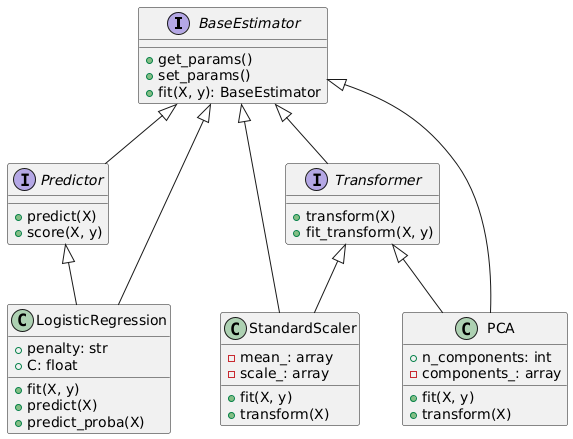

## Mecanismos de Composición: *Pipeline*

```python
# Ejemplo directo del paper
estimador = Pipeline([
    ("scala", StandardScaler()),
    ("pca", PCA(n_components=10)),
    ("clf", LogisticRegression())
])

estimador.fit(X, y)
estimador.transform(X0)
estimador.predict(X1)
```

- Encadena transformadores y un estimador final
- Maneja automáticamente el flujo de datos
- Permite optimización global de parámetros

### Paralelismos

1. **Composite Pattern**
   - Encadena componentes simples y complejos uniformemente
   - Pero menos flexible: solo secuencial, sin ramificaciones reales
   - El orden es crítico y no modificable en runtime
2. **Builder Pattern**
   - Construye un modelo complejo paso a paso
   - Pero sin director explícito ni validación entre pasos
   - No hay garantía de compatibilidad hasta runtime
3. **Chain of Responsibility**
   - Cada paso procesa y pasa al siguiente
   - Pero sin capacidad de decisión o routing
   - El flujo es estrictamente lineal

## Mecanismos de Composición: *Pipeline*

```python
# Ejemplo directo del paper
estimador = Pipeline([
    ("scala", StandardScaler()),
    ("pca", PCA(n_components=10)),
    ("clf", LogisticRegression())
])
estimador.fit(X, y)
estimador.transform(X0)
estimador.predict(X1)
```

### Críticas

1. **Rigidez Estructural**
   - Flujo estrictamente lineal
   - No permite bifurcaciones condicionales
   - Difícil implementar lógica compleja

2. **Transparencia de Datos**
   - No hay validación explícita entre pasos
   - Asume compatibilidad de tipos
   - Errores pueden aparecer tarde en el pipeline

3. **Gestión de Estado**
   - Estado distribuido entre componentes
   - Difícil rastrear transformaciones
   - Problemas potenciales con memoria en pipelines largos

### ¿Por qué funciona igual?

- Refleja el flujo natural de ML
- Simplicidad conceptual
- Trade-off efectivo entre flexibilidad y usabilidad

## Mecanismos de Composición: *FeatureUnion*

```python
# Del paper
union = FeatureUnion([
    ("pca", PCA()),
    ("kpca", KernelPCA())
])

union.fit_tranform(X)
union.transform(X)
```

- Combina múltiples transformadores en paralelo
- Concatena sus salidas
- Permite procesamiento paralelo de características

### Paralelismos

1. **Facade Pattern**
   - Unifica diferentes transformaciones bajo una interfaz simple
   - Pero con menor flexibilidad en la interfaz resultante
   - Oculta complejidad al costo de control

2. **Composite Pattern**
   - Combina múltiples transformadores como uno solo
   - Pero solo en paralelo, sin jerarquías complejas
   - Limitado a concatenación horizontal

3. **Adapter Pattern**
   - Hace que diferentes transformaciones encajen en un formato común
   - Pero fuerza una estructura de salida específica
   - No permite adaptaciones personalizadas del resultado

## Mecanismos de Composición: *FeatureUnion*

```python
# Del paper
union = FeatureUnion([
    ("pca", PCA()),
    ("kpca", KernelPCA())
])

union.fit_tranform(X)
union.transform(X)
```

### Críticas

1. **Inflexibilidad en la Combinación**
   - Solo permite concatenación simple
   - No hay operaciones entre features
   - No permite interacciones entre transformadores

2. **Gestión de Memoria**
   - Mantiene todas las features en memoria
   - Puede ser ineficiente con grandes conjuntos
   - No hay procesamiento lazy o streaming

3. **Pérdida de Identidad**
   - Difícil rastrear origen de features
   - No mantiene metadatos de transformaciones
   - Complica el debugging y análisis

### ¿Por qué funciona igual?

- Simplicidad conceptual clara
- Cubre el caso de uso más común
- Se integra naturalmente con Pipeline

##  Meta-Estimadores 

El paper describe los meta-estimadores como una forma de extensión:

```python
# Ejemplo del paper
clasificador = OneVsOneClassifier(LogisticRegression())
```
- Toman un estimador base como parámetro
- Modifican su comportamiento
- Mantienen la misma interfaz
- Ejemplos del paper:
  - GridSearchCV
  - OneVsOneClassifier
  - Pipeline (también es un meta-estimador)

### Paralelismos

1. **Decorator Pattern**
   - Envuelve estimadores añadiendo funcionalidad
   - Pero modifica comportamiento interno, no solo externo
   - Más invasivo que un decorator tradicional

2. **Strategy Pattern**
   - Permite intercambiar estimadores base
   - Pero con fuerte acoplamiento al comportamiento del meta-estimador
   - No es una estrategia pura, hay estado compartido

3. **Template Method Pattern**
   - Define estructura algorítmica general
   - Pero invierte el control: el meta-estimador controla al estimador base
   - Mezcla template con implementación

##  Meta-Estimadores 

El paper describe los meta-estimadores como una forma de extensión:

```python
# Ejemplo del paper
clasificador = OneVsOneClassifier(LogisticRegression())
```
### Críticas

1. **Violación de Encapsulamiento**
   - Accede y modifica el estado interno del estimador base
   - Asume conocimiento de la implementación
   - Puede romper el principio de least surprise

2. **Complejidad de Estado**
   - Estado distribuido entre meta-estimador y estimador base
   - Difícil rastrear modificaciones
   - Problemas potenciales en serialización/deserialización

3. **Jerarquía Implícita**
   - No hay límite claro en niveles de meta-estimación
   - Posible complejidad exponencial en anidamiento
   - Debugging complejo en meta-estimadores anidados

### ¿Por qué funciona igual?

- Permite extensibilidad sin modificar código base
- Resuelve problemas comunes (cross-validation, multiclass) elegantemente
- Mantiene la interfaz consistente del estimador

## Y todo junto?

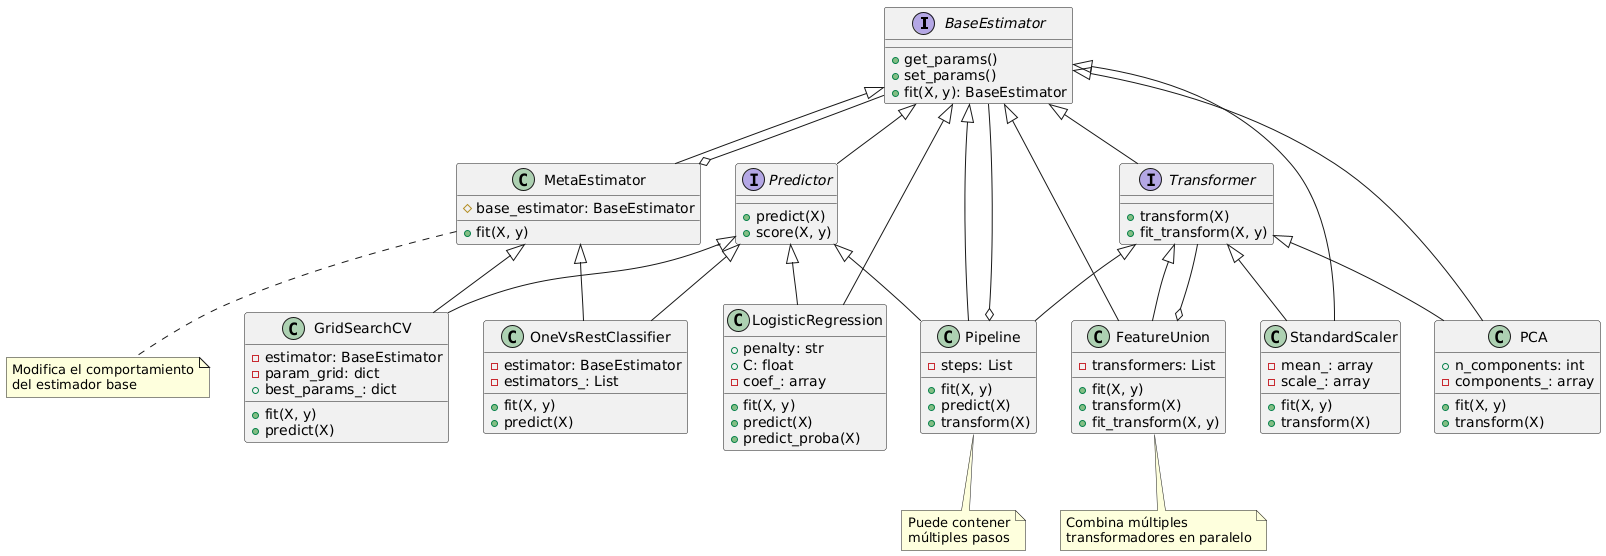

## Extensibilidad y Duck Typing 

El paper enfatiza el uso de duck typing en lugar de herencia:

```python
# Como se sugiere en el paper
class MiTransformador:
    def fit(self, X, y=None):
        # Realizar ajuste
        return self
        
    def transform(self, X):
        # Realizar transformación
        return X_modificado

```

- No requiere herencia de clases base (podes heredar, por comodidad)
- Se define por la interfaz, no por la jerarquía
- Facilita la extensión por usuarios externos

## Extensibilidad y Duck Typing 

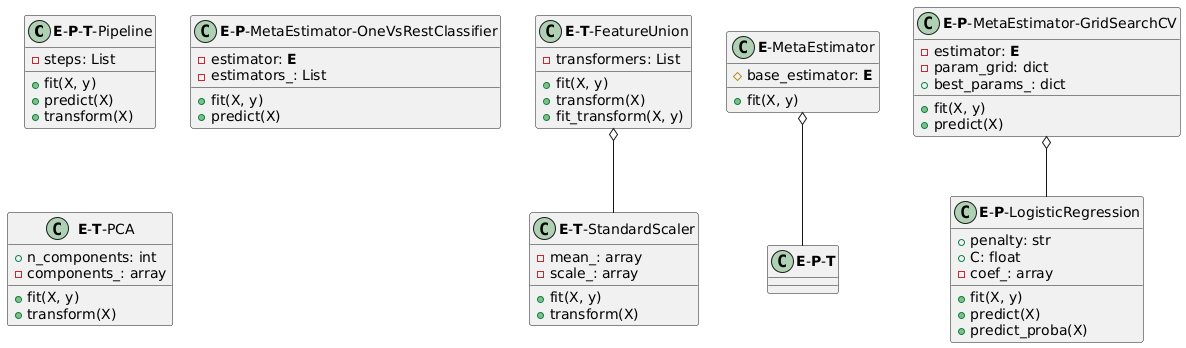

# Discusión Final

Puntos clave del paper sobre el éxito del diseño:

- Interfaz consistente y simple
- Facilidad de composición
- Extensibilidad natural
- Balance entre flexibilidad y convención
- Soportan errores de tipos, signature y protocolos incompletos 🤷